<a href="https://colab.research.google.com/github/LabWorkAndAnalysis/YAG/blob/main/beam_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YAG laser beam characterization
Open this notebook in Google Colab, select **Runtime → Run all**, and upload `beam_measurements.xlsx` when prompted. No code edits are needed.

The notebook also accepts a CSV export of the `Measurements` sheet. The workbook contains the corrected propagation distances and the new 875 V data. Add future measurements as rows with unique record IDs. Settings and status definitions are on the `Setup` sheet.

The downloaded ZIP contains all numerical results, intermediate calculations, CSV and LaTeX tables, and vector PDF/SVG and 300 dpi PNG plots. Gaussian parameters are conditional on burn-mark diameter = Gaussian 1/e² diameter, M² = 1 and an upstream waist. Nonpositive-growth sensitivity cases are recorded as unavailable.


Upload the input workbook (.xlsx) or long-format Measurements CSV.


Saving beam_measurements.xlsx to beam_measurements.xlsx
{
  "input_records": 64,
  "numerical_marks": 35,
  "status_counts": {
    "N": 26,
    "ND": 11,
    "B": 9,
    "U": 18
  },
  "min_w0_um": 38.70890354523427,
  "max_w0_um": 92.85843994871904,
  "min_theta_mrad": 1.8236453201593192,
  "max_theta_mrad": 4.374726327546041,
  "min_distance_in_zR": 28.700131333083508,
  "multirate_range_counts": {
    "0.5": 6,
    "0.0": 15,
    "1.0": 1
  }
}
Results: /content/beam_results_20261008_144458
Download: /content/beam_results_20261008_144458.zip


,voltage_V,axis,w0_mm,z0_m,theta_mrad,zR_m,diameter_rms_mm
0,875,Dx,0.077392,-1.091196,2.188100,0.035369,6.280370e-16
1,875,Dy,0.051608,-0.787136,3.281294,0.015728,0.000000e+00
4,900,Dx,0.092858,-1.410586,1.823645,0.050919,2.357023e-01
5,900,Dy,0.038709,-0.634900,4.374726,0.008848,0.000000e+00
8,950,Dx,0.058328,-0.991858,2.903245,0.020091,8.315422e-02
9,950,Dy,0.045994,-0.777700,3.681771,0.012492,2.043416e-01
12,1000,Dx,0.064273,-1.258662,2.634713,0.024395,3.246670e-01
13,1000,Dy,0.053765,-1.015179,3.149647,0.017070,2.151618e-01
16,1050,Dx,0.070965,-1.612513,2.386266,0.029739,0.000000e+00
17,1050,Dy,0.065507,-1.451405,2.585087,0.025340,1.666667e-01


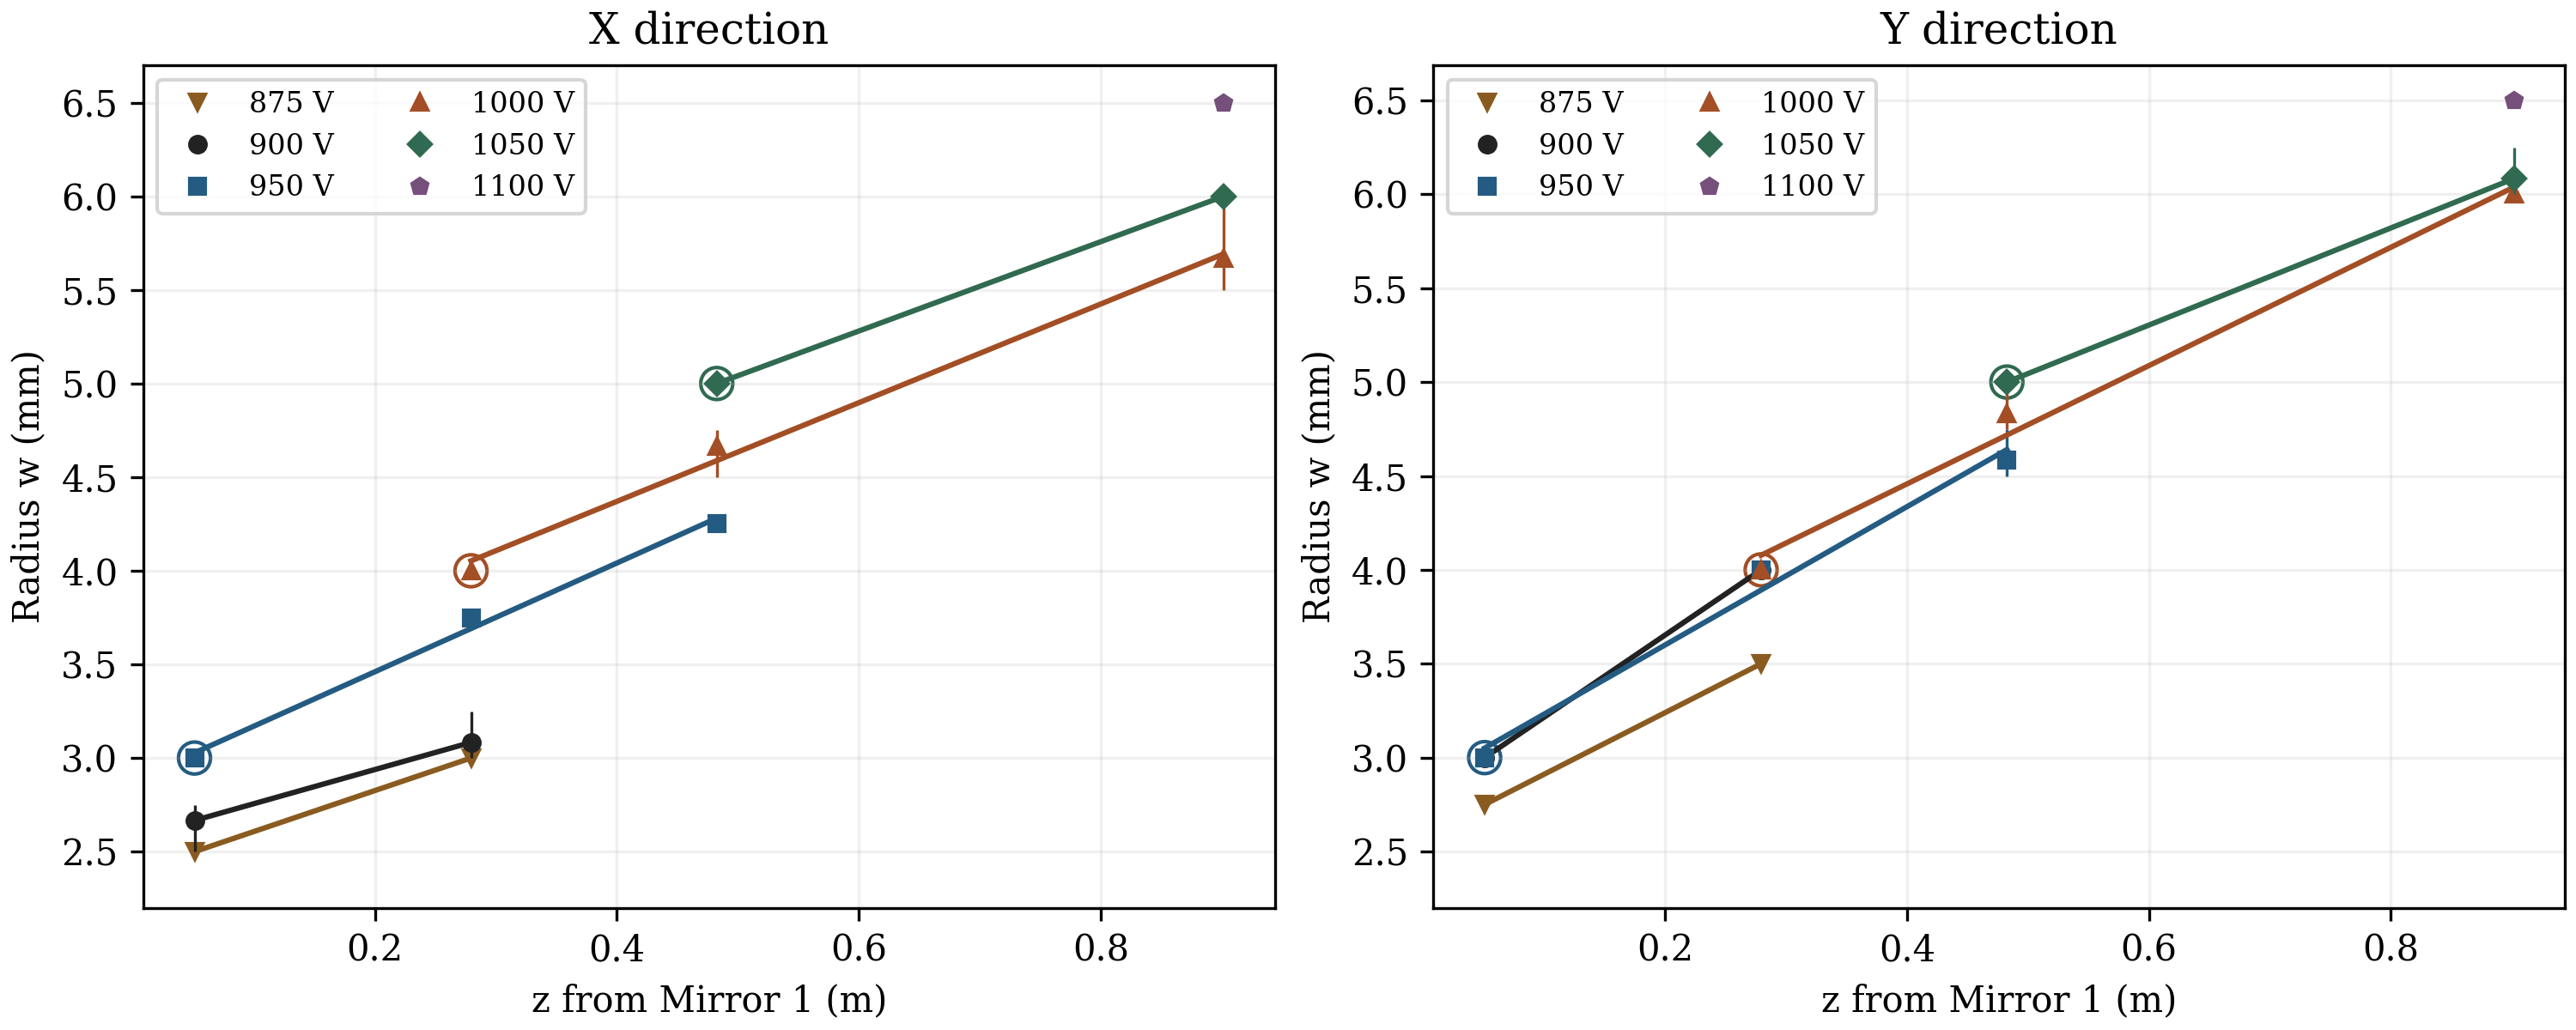

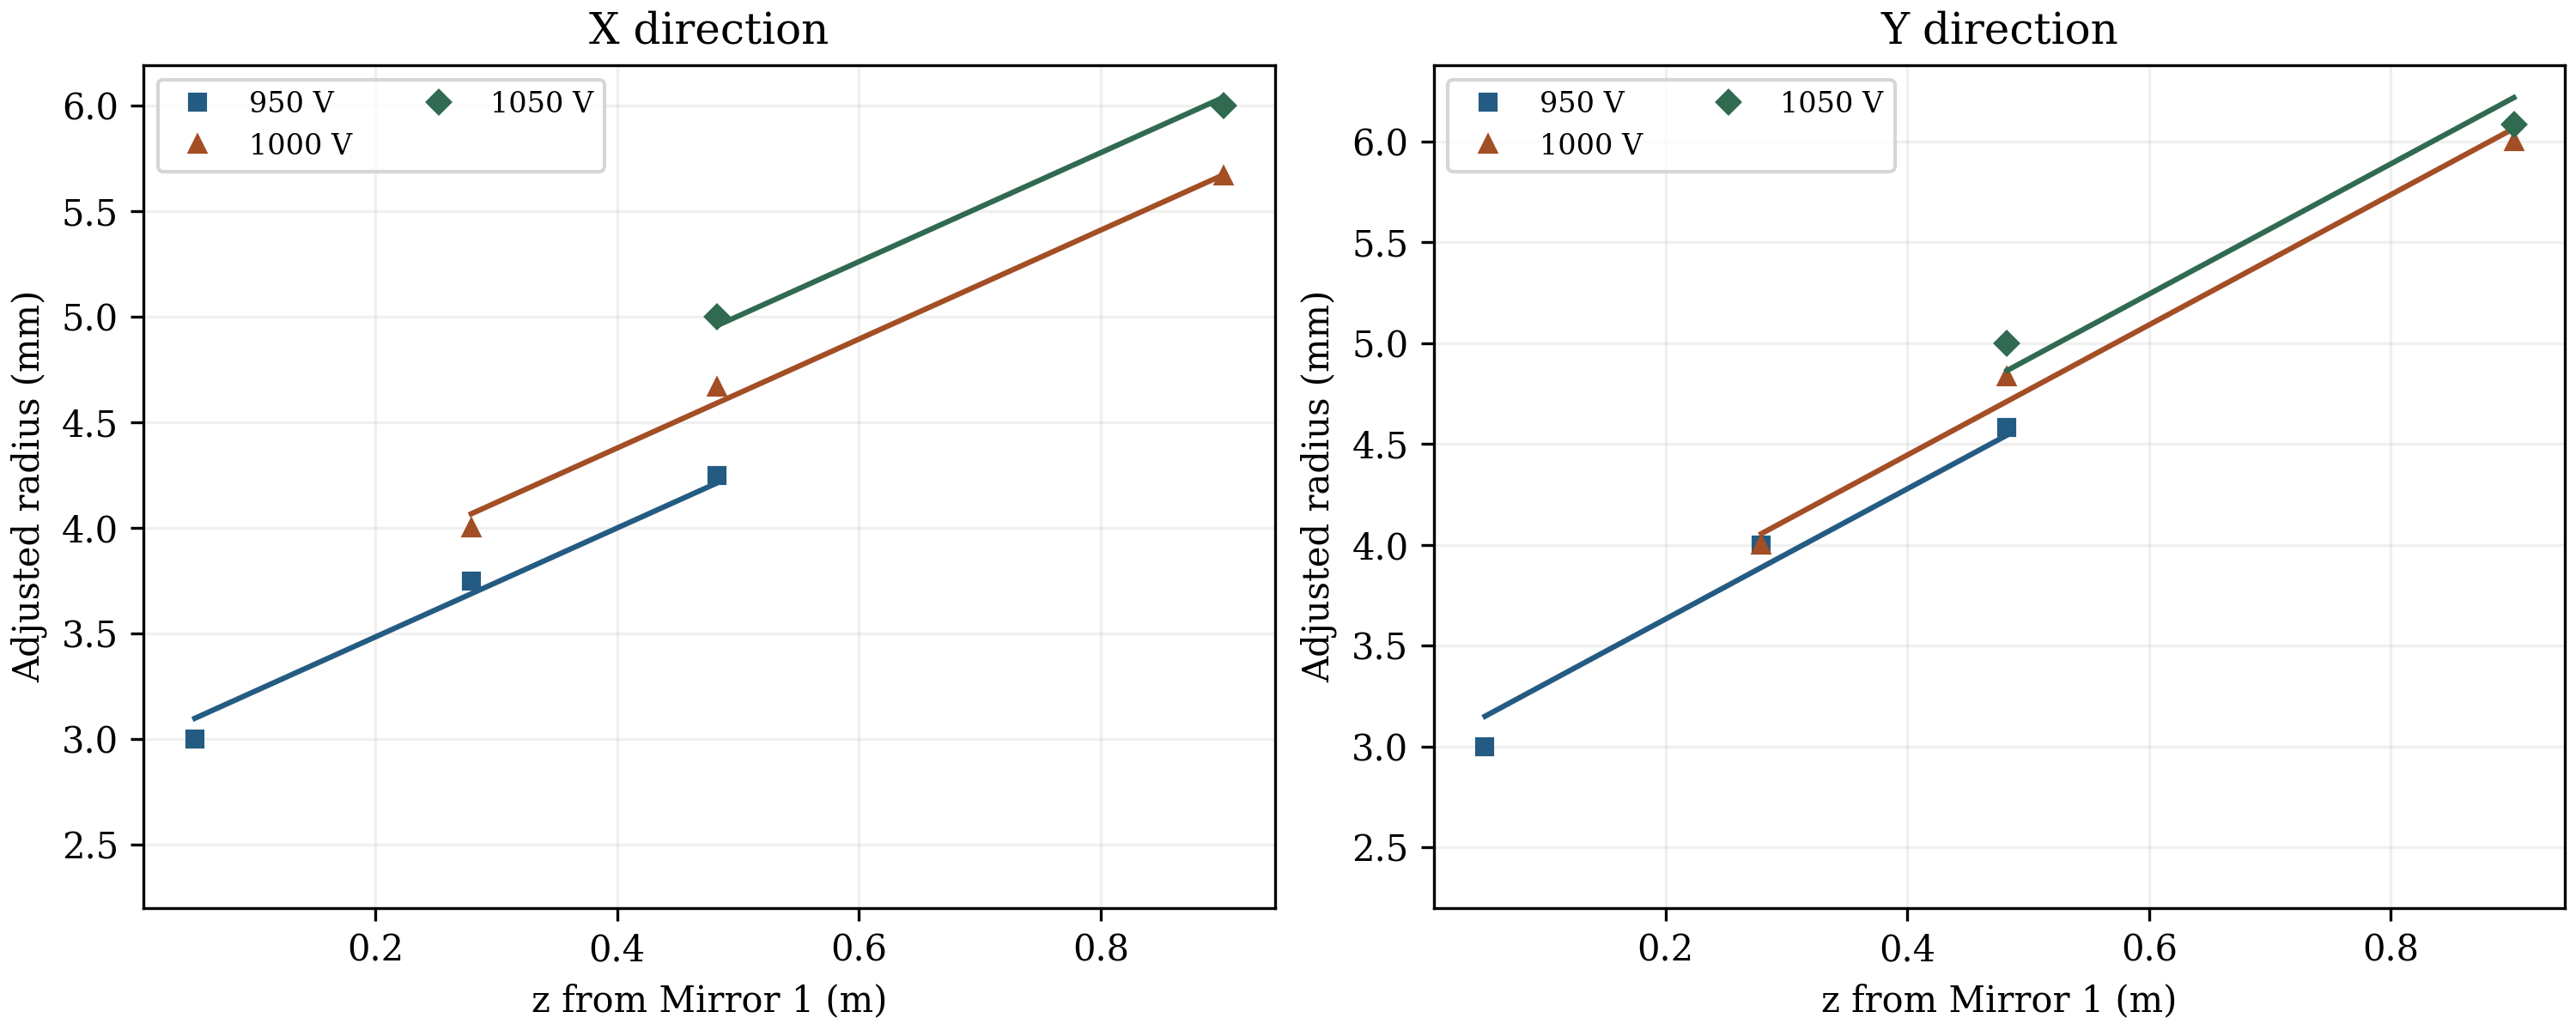

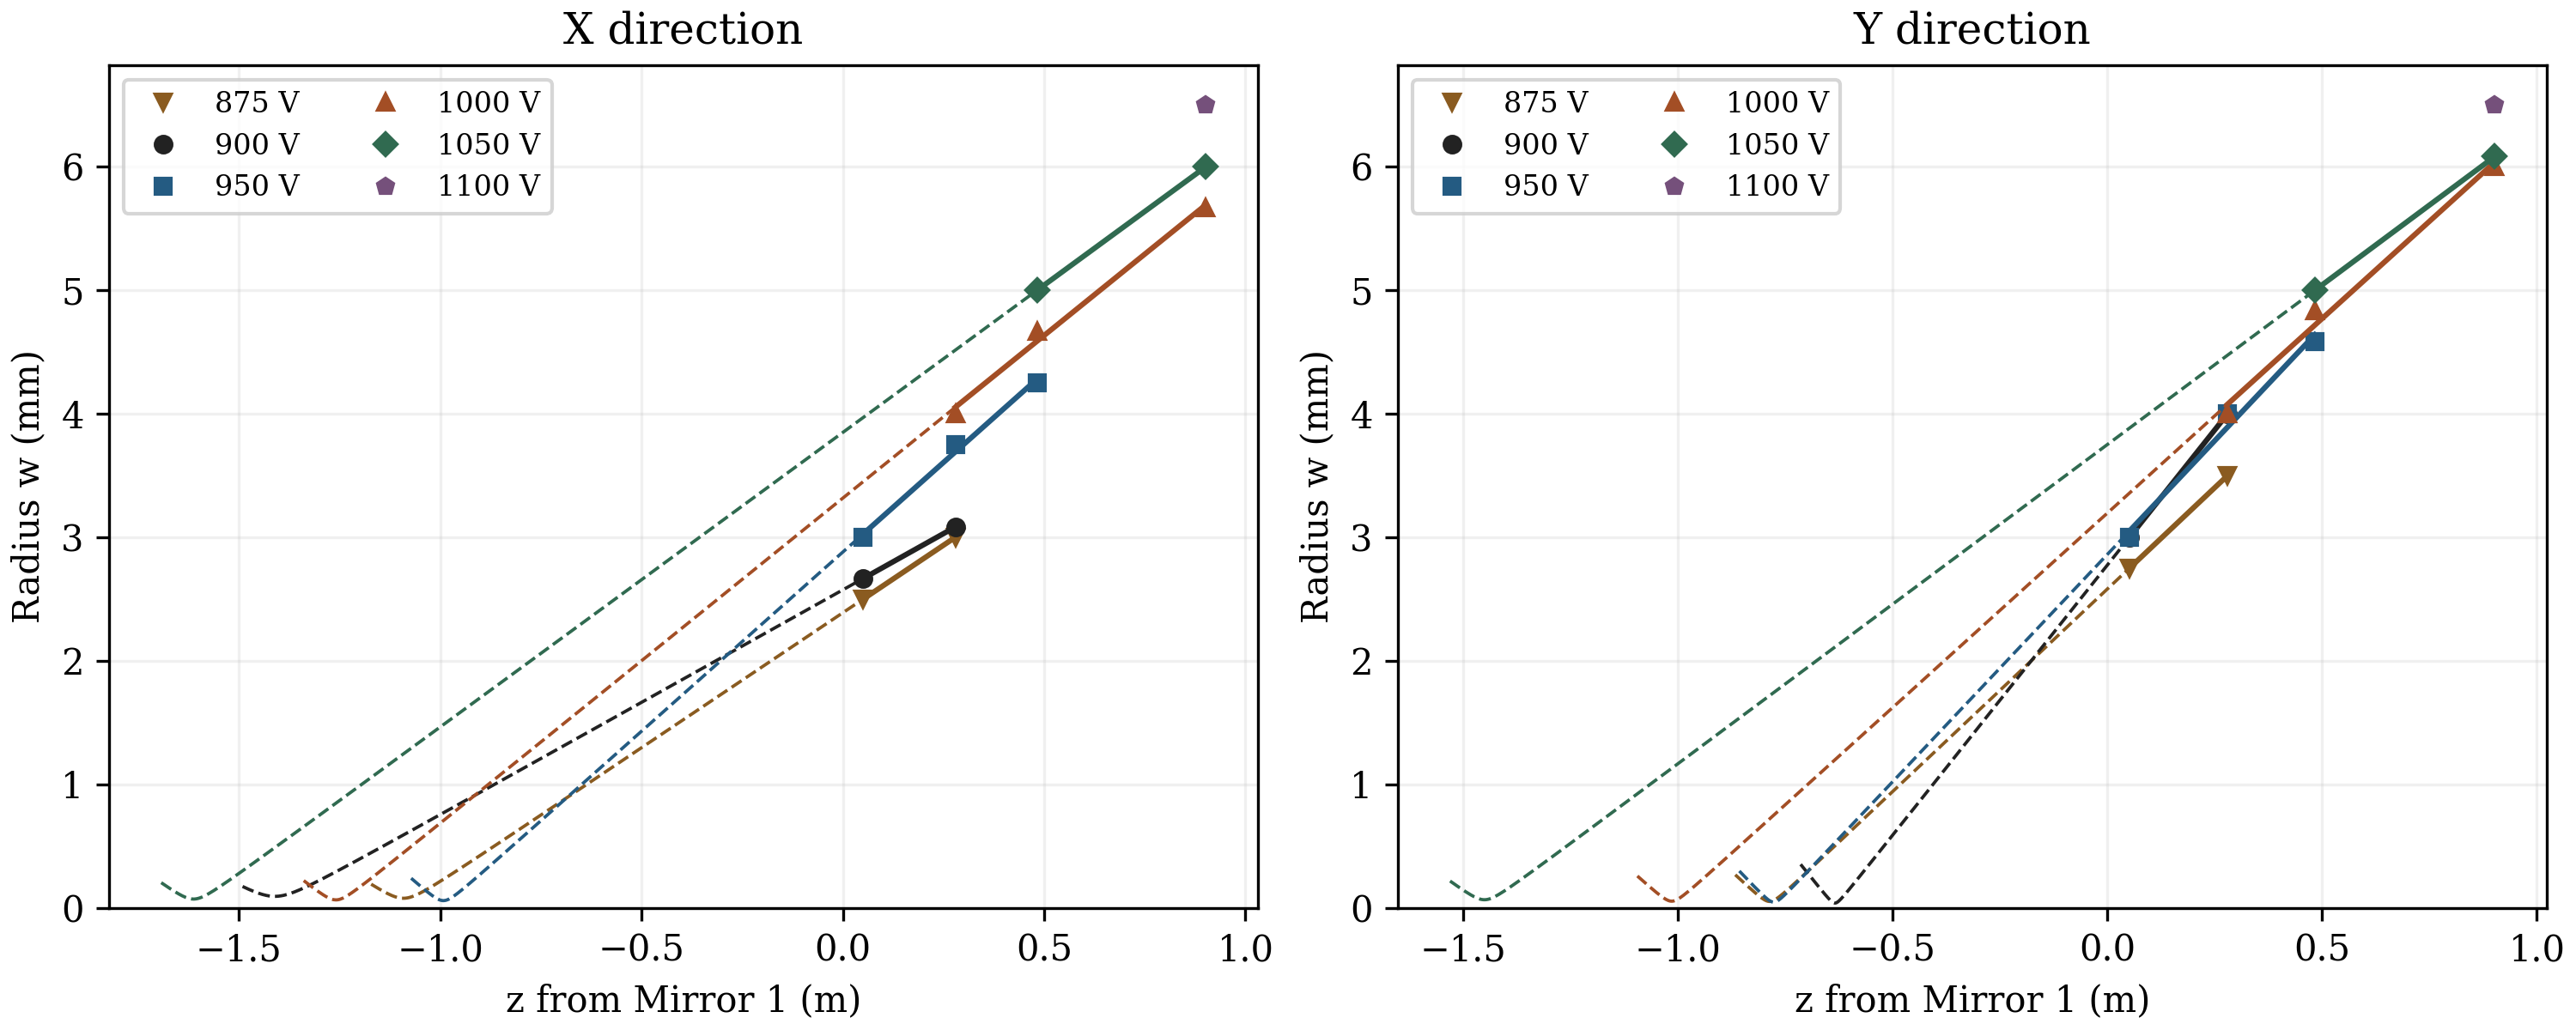

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
#!/usr/bin/env python3
"""Ideal-Gaussian estimates from original widths, following Edmund Optics Eqs 2--5.
All numbers are conditional on mark diameter=2w, lambda=532 nm, M^2=1,
and the measured planes lying downstream of the waist. Requires scipy/numpy.
"""
import numpy as np
from scipy.optimize import least_squares
from itertools import product
import math
WAVELENGTH_NM=532.0
K=WAVELENGTH_NM*1e-3/math.pi # w in mm, z in m: w=sqrt(w0^2+(K/w0)^2*(z-z0)^2)

def fit_gaussian(z,y):
    z=np.asarray(z);y=np.asarray(y)
    slope,intercept=np.polyfit(z,y,1)
    if len(set(z))<2 or slope<=1e-12:
        raise ValueError("No positive measured growth for the selected upstream branch")
    wseed=K/slope;zseed=-intercept/slope
    def residual(p):
        w0=np.exp(p[0]);return np.hypot(w0,K/w0*(z-p[1]))-y
    fits=[]
    for factor in (.3,1,3):
        result=least_squares(residual,[np.log(wseed*factor),min(zseed,z.min()-.001)],bounds=([-24,z.min()-max(1e4,abs(zseed)*10)],[np.log(y.min()),z.min()]),max_nfev=3000,xtol=1e-12,ftol=1e-12,gtol=1e-12)
        fits.append(result)
    best=min(fits,key=lambda r:sum(r.fun**2));w0=np.exp(best.x[0]);z0=best.x[1]
    # Polish the optimum with the analytic derivatives printed in the report.
    # This aligns the last displayed digits with the explicit worked iteration.
    for _ in range(8):
        d=z-z0;g=np.hypot(w0,K/w0*d);e=g-y
        J=np.column_stack([(w0-K*K*d*d/w0**3)/g,-(K/w0)**2*d/g])
        du,dv=np.linalg.lstsq(J,-e,rcond=None)[0]
        if w0+du<=0 or z0+dv>=z.min():break
        w0+=du;z0+=dv
        if abs(du)<1e-13 and abs(dv)<1e-11:break
    err=np.hypot(w0,K/w0*(z-z0))-y
    assert float(err@err)<=float(best.fun@best.fun)+1e-12
    # Independent parameterization, in theta instead of logarithmic waist.
    other=least_squares(lambda p:np.hypot(K/p[0],p[0]*(z-p[1]))-y,[slope,min(zseed,z.min()-.001)],bounds=([1e-12,z.min()-max(1e4,abs(zseed)*10)],[1e4,z.min()]),xtol=1e-12,ftol=1e-12,gtol=1e-12,max_nfev=3000)
    assert abs(K/other.x[0]-w0)<2e-7 and abs(other.x[1]-z0)<5e-6
    theta=K/w0;zr=w0/theta
    # SI check and exact Gaussian propagation check.
    assert abs(math.pi*(w0*1e-3)**2/(WAVELENGTH_NM*1e-9)-zr)<1e-12
    assert abs(theta*1e-3-WAVELENGTH_NM*1e-9/(math.pi*w0*1e-3))<1e-12
    assert np.max(abs(w0*np.sqrt(1+((z-z0)/zr)**2)-y-err))<1e-10
    return dict(w0_mm=float(w0),z0_m=float(z0),theta_mrad=float(theta),zR_m=float(zr),diameter_rms_mm=float(2*np.sqrt(np.mean(err**2))),diameter_residuals_mm=(2*err).tolist(),n=len(z),unique_planes=len(set(z)),domain_m=[float(z.min()),float(z.max())])

def two_plane_solutions(z,r):
    L=(z[1]-z[0])*1000;k=WAVELENGTH_NM*1e-6/math.pi
    A=1+(r[1]**2-r[0]**2)**2/(4*k*k*L*L);B=(r[0]**2+r[1]**2)/2;C=k*k*L*L/4
    disc=B*B-4*A*C;assert disc>0
    big=(B+math.sqrt(disc))/(2*A);small=C/(A*big)
    out=[]
    for s in (big,small):
        distance=(s*(r[1]**2-r[0]**2)/(2*k*k*L)-L/2)/1000
        w=math.sqrt(s);z0=z[0]-distance
        assert np.allclose(np.hypot(w,K/w*(np.array(z)-z0)),r,atol=1e-7)
        out.append({'w0_mm':w,'z0_m':z0})
    return out


# Input/output and complete numerical reproduction of the report.
from pathlib import Path
import argparse, collections, csv, hashlib, json, platform, shutil, sys
import pandas as pd

DEFAULTS={'wavelength_nm':532.0,'diameter_shift_mm':0.25,'z_reference_m':0.4826}
AXES=('Dx','Dy')

def read_input(path):
    """Read the supplied long-format Measurements sheet or its CSV export.
    Required columns: voltage_V, frequency_Hz, position, z_in, Dx_mm,
    Dy_mm, status. record_id and remarks are optional. Derived columns
    are recomputed, never used as observations. Blank widths remain missing.
    """
    path=Path(path); settings=DEFAULTS.copy()
    if path.suffix.lower()=='.csv':df=pd.read_csv(path,keep_default_na=False)
    elif path.suffix.lower()=='.xlsx':
        df=pd.read_excel(path,sheet_name='Measurements',keep_default_na=False)
        book=pd.ExcelFile(path)
        if 'Setup' in book.sheet_names:
            setup=pd.read_excel(path,sheet_name='Setup',keep_default_na=False)
            for _,row in setup.iterrows():
                if str(row.iloc[0]) in settings:settings[str(row.iloc[0])]=float(row.iloc[1])
    else:raise ValueError('Upload the supplied .xlsx template or a long-format .csv file.')
    required=['voltage_V','frequency_Hz','position','z_in','Dx_mm','Dy_mm','status']
    missing=set(required)-set(df.columns)
    if missing:raise ValueError('Missing columns: '+', '.join(sorted(missing))+'. Use the supplied long-format template.')
    df=df.loc[~df[required].apply(lambda r:all(str(v).strip()=='' for v in r),axis=1)].copy()
    if df.empty:raise ValueError('No measurement records.')
    for c in ['voltage_V','frequency_Hz','position','z_in']:
        df[c]=pd.to_numeric(df[c],errors='raise')
        if not np.isfinite(df[c]).all():raise ValueError(c+' must be finite.')
    for c in ['Dx_mm','Dy_mm']:
        df[c]=pd.to_numeric(df[c].where(df[c]!='',np.nan),errors='raise')
        if not np.isfinite(df[c].dropna()).all():raise ValueError(c+' contains a non-finite width.')
    if (df.voltage_V<=0).any() or (df.frequency_Hz<=0).any():raise ValueError('Voltage and repetition rate must be positive.')
    if (df.position<1).any() or (df.position%1!=0).any():raise ValueError('position must be a positive plane number.')
    df['status']=df.status.astype(str).str.strip().str.upper()
    if not set(df.status)<=set(['N','B','ND','U']):raise ValueError('status must be N, B, ND or U.')
    valid=df.status.isin(['N','B']);present=df.Dx_mm.notna() & df.Dy_mm.notna()
    if not (valid==present).all() or (df.Dx_mm.notna()!=df.Dy_mm.notna()).any():raise ValueError('Both widths are required for N/B; both must be blank for ND/U.')
    if ((df.loc[valid,['Dx_mm','Dy_mm']]<=0).any()).any():raise ValueError('Measured diameters must be positive; a missing mark is not zero.')
    if df.groupby('position').z_in.nunique().max()!=1:raise ValueError('Each plane number must identify one propagation coordinate.')
    if df.groupby('z_in').position.nunique().max()!=1:raise ValueError('Use one plane number per distinct z coordinate.')
    if 'record_id' not in df:df['record_id']=['R%04d'%i for i in range(1,len(df)+1)]
    if df.record_id.astype(str).str.strip().eq('').any() or df.record_id.duplicated().any():raise ValueError('record_id must be nonblank and unique. Give repeat measurements distinct IDs.')
    if settings['wavelength_nm']<=0 or settings['diameter_shift_mm']<0:raise ValueError('Invalid wavelength or diameter shift.')
    df['z_m']=df.z_in*.0254
    for a in AXES:df['w'+a[-1]+'_mm']=df[a+'_mm']/2
    df['Deq_mm']=np.sqrt(df.Dx_mm*df.Dy_mm)
    df=df.sort_values(['voltage_V','frequency_Hz','z_m','record_id']).reset_index(drop=True)
    return df,settings

def line_fit(z,y):
    z=np.asarray(z,dtype=float);y=np.asarray(y,dtype=float);dz=z-z.mean();dy=y-y.mean()
    cov=float(dz@dy);var=float(dz@dz)
    if var<=0:return None
    slope=cov/var;intercept=float(y.mean()-slope*z.mean());err=intercept+slope*z-y
    # Independent linear algebra evaluation.
    other=np.linalg.lstsq(np.column_stack([np.ones(len(z)),z]),y,rcond=None)[0]
    assert np.allclose(other,[intercept,slope],atol=1e-10)
    return dict(intercept_mm=intercept,slope_mm_per_m=slope,rms_mm=float(np.sqrt(np.mean(err**2))),
                n=len(z),z_mean_m=float(z.mean()),y_mean_mm=float(y.mean()),cov_mm_m=cov,var_m2=var)

def nullable_fit(z,w):
    if len(set(z))<2:return None,'one longitudinal plane'
    if line_fit(z,w)['slope_mm_per_m']<=1e-12:return None,'no positive growth: selected upstream branch not fitted'
    try:return fit_gaussian(z,w),'fitted'
    except (ValueError,AssertionError,RuntimeError) as ex:return None,'fit failed: '+str(ex)

def analyze_data(df,settings):
    global K,WAVELENGTH_NM
    WAVELENGTH_NM=settings['wavelength_nm'];K=WAVELENGTH_NM*1e-3/math.pi
    records=json.loads(df.to_json(orient='records'));obs=df[df.Dx_mm.notna()].copy()
    means={};growth={};linear={};fits={};per_rate=[];branches={};sens={};corner_rows=[];fit_status=[];residuals=[];rate_ranges=[];curv=[]
    for v,allv in obs.groupby('voltage_V',sort=True):
        v=int(v) if float(v).is_integer() else float(v);mv=[]
        for z,g in allv.groupby('z_m',sort=True):
            mv.append(dict(position=int(g.position.iloc[0]),z_m=float(z),n=len(g),status='B' if 'B' in set(g.status) else 'N',
                           **{a:float(g[a+'_mm'].mean()) for a in ('Dx','Dy','Deq')}))
            for a in AXES:
                byrate=g.groupby('frequency_Hz')[a+'_mm'].mean()
                rate_ranges.append(dict(voltage_V=v,position=int(g.position.iloc[0]),axis=a,n_rates=len(byrate),
                                        diameter_range_mm=float(byrate.max()-byrate.min())))
        means[v]=mv
        if len(mv)>=2:
            linear[v]={a:line_fit(allv.z_m,allv[a+'_mm']) for a in AXES}
            growth[v]=dict(length_m=mv[-1]['z_m']-mv[0]['z_m'],percent_eq=100*(mv[-1]['Deq']/mv[0]['Deq']-1),
                **{a+'_change_mm':mv[-1][a]-mv[0][a] for a in AXES})
        fits[v]={}
        for subset,sub in [('all',allv),('normal',allv[allv.status=='N'])]:
            axes={}
            for a in AXES:
                f,status=nullable_fit(sub.z_m.to_numpy(),sub[a+'_mm'].to_numpy()/2)
                fit_status.append(dict(voltage_V=v,subset=subset,axis=a,status=status,n=len(sub),n_planes=sub.z_m.nunique()))
                if f is not None:
                    axes[a]=f
                    # SI evaluation independent of mixed-unit fitting.
                    wr=f['w0_mm']*.001;th=WAVELENGTH_NM*1e-9/(np.pi*wr)
                    pred=2*np.sqrt(wr**2+(th*(sub.z_m.to_numpy()-f['z0_m']))**2)*1000
                    assert np.allclose(pred-sub[a+'_mm'],f['diameter_residuals_mm'],atol=1e-9)
                    for (_,r),pp in zip(sub.iterrows(),pred):
                        residuals.append(dict(record_id=r.record_id,voltage_V=v,frequency_Hz=r.frequency_Hz,position=r.position,
                            z_m=r.z_m,axis=a,subset=subset,measured_diameter_mm=r[a+'_mm'],fitted_diameter_mm=pp,residual_mm=pp-r[a+'_mm']))
            if axes:fits[v][subset]=axes
        for hz,g in allv.groupby('frequency_Hz',sort=True):
            item={'voltage':v,'Hz':float(hz)}
            for a in AXES:
                f,status=nullable_fit(g.z_m.to_numpy(),g[a+'_mm'].to_numpy()/2)
                if f is not None:item[a]=f
            if len(item)>2:per_rate.append(item)
        if len(mv)<2:continue
        z=np.array([m['z_m'] for m in mv]);nn=np.array([m['n'] for m in mv])
        for a in AXES:
            w=np.array([m[a]/2 for m in mv]);key=str(v)+a
            if len(mv)==2:
                try:branches[key]=two_plane_solutions(z,w)
                except (ValueError,AssertionError):branches[key]=[]
            if len(mv)<=12: # Exact enumeration; never replace with a hidden random sample.
                results=[];rejected=0
                for shift in product((-settings['diameter_shift_mm'],settings['diameter_shift_mm']),repeat=len(mv)):
                    ww=w+np.array(shift)/2
                    if np.any(ww<=0):f=None;status='nonpositive perturbed radius'
                    else:f,status=nullable_fit(np.repeat(z,nn),np.repeat(ww,nn))
                    c=dict(voltage_V=v,axis=a,diameter_shifts_mm=list(shift),status=status,
                           perturbed_diameters_mm=(2*ww).tolist())
                    if f is not None:c.update({k:f[k] for k in ('w0_mm','z0_m','theta_mrad','zR_m')});results.append(f)
                    else:rejected+=1
                    corner_rows.append(c)
                sens[key]=dict(assumed_diameter_bound_mm=settings['diameter_shift_mm'],n_corners=2**len(mv),excluded_corners=rejected,
                    w0_mm_range=[min(f['w0_mm'] for f in results),max(f['w0_mm'] for f in results)] if results else None,
                    z0_m_range=[min(f['z0_m'] for f in results),max(f['z0_m'] for f in results)] if results else None)
            else:sens[key]=dict(status='not enumerated: more than 12 planes',n_corners=2**len(mv))
            if len(mv)==3:
                yy=w*w;t12=(yy[1]-yy[0])/(z[1]-z[0]);t23=(yy[2]-yy[1])/(z[2]-z[1]);c=(t23-t12)/(z[2]-z[0])
                assert np.isclose(np.polyfit(z,yy,2)[0],c,rtol=1e-10,atol=1e-10)
                curv.append(dict(voltage=v,axis=a,C_mm2_per_m2=float(c),t12_mm2_per_m=float(t12),t23_mm2_per_m=float(t23)))
    # Shared slope uses every numerical mark at voltages with >=2 measured planes.
    eligible=[v for v,m in means.items() if len(m)>=2];pooled=obs[obs.voltage_V.isin(eligible)];norm={};norm_sums=[]
    for a in AXES:
        Q=P=0.;groups=[]
        for v,g in pooled.groupby('voltage_V',sort=True):
            z=g.z_m.to_numpy();y=g[a+'_mm'].to_numpy();xc=z-z.mean();yc=y-y.mean()
            q=float(xc@xc);p=float(xc@yc);Q+=q;P+=p
            groups.append((v,z.mean(),y.mean()));norm_sums.append(dict(voltage_V=v,axis=a,n=len(g),z_mean_m=float(z.mean()),D_mean_mm=float(y.mean()),Q_m2=q,P_mm_m=p))
        if not eligible:continue
        b=P/Q;aa={v:float(ym-b*(zm-settings['z_reference_m'])) for v,zm,ym in groups}
        yy=pooled[a+'_mm'].to_numpy();zz=pooled.z_m.to_numpy();vs=pooled.voltage_V.to_numpy()
        pred=np.array([aa[v] for v in vs])+b*(zz-settings['z_reference_m']);error=pred-yy
        mat=np.column_stack([vs==v for v in eligible]+[zz-settings['z_reference_m']]);coef=np.linalg.lstsq(mat,yy,rcond=None)[0]
        assert np.allclose(coef,np.r_[list(aa.values()),b],atol=1e-10)
        norm[a]=dict(a_mm=aa,slope_mm_per_m=b,rms_diameter_mm=float(np.sqrt(np.mean(error**2))),n=len(pooled),residual_dof=len(pooled)-len(eligible)-1,Q_m2=Q,P_mm_m=P)
    # Worked 1000 V / X calculation; omitted, with reason, if inputs absent.
    worked=[];detail={}
    if 1000 in fits and 'Dx' in fits[1000].get('all',{}):
        g=obs[obs.voltage_V==1000];z=g.z_m.to_numpy();w=g.Dx_mm.to_numpy()/2
        lf=line_fit(z,w);uv=np.array([K/lf['slope_mm_per_m'],-lf['intercept_mm']/lf['slope_mm_per_m']])
        for it in range(3):
            u,v=uv;d=z-v;pred=np.hypot(u,K/u*d);err=pred-w
            J=np.column_stack([(u-K*K*d*d/u**3)/pred,-(K/u)**2*d/pred]);H=J.T@J;rhs=-J.T@err;delta=np.linalg.lstsq(J,-err,rcond=None)[0]
            worked.append(dict(iteration=it,w0_mm=float(u),z0_m=float(v),S_mm2=float(err@err),JTJ=H.tolist(),rhs=rhs.tolist(),update=delta.tolist(),
                determinant=float(np.linalg.det(H)),numerator_u=float(rhs[0]*H[1,1]-H[0,1]*rhs[1]),numerator_v=float(H[0,0]*rhs[1]-H[0,1]*rhs[0])))
            uv+=delta
        f=fits[1000]['all']['Dx'];assert np.allclose(uv,[f['w0_mm'],f['z0_m']],atol=1e-7)
        pred=np.hypot(f['w0_mm'],f['theta_mrad']*(z-f['z0_m']));rawS=float(np.sum((pred-w)**2));within=0.;between=0.;plane_steps=[]
        for m in means[1000]:
            gg=g[g.z_m==m['z_m']];wr=gg.Dx_mm.to_numpy()/2;wm=wr.mean();zv=m['z_m'];fitw=float(np.hypot(f['w0_mm'],f['theta_mrad']*(zv-f['z0_m'])))
            withinp=float(np.sum((wr-wm)**2));betweenp=len(wr)*(fitw-wm)**2;within+=withinp;between+=betweenp
            u=worked[0]['w0_mm'];v=worked[0]['z0_m'];d=zv-v;gi=np.hypot(u,K/u*d)
            plane_steps.append(dict(position=m['position'],z_m=zv,n=len(wr),D_mean_mm=2*wm,w_mean_mm=wm,predicted_radius_mm=fitw,
                mean_radius_residual_mm=fitw-wm,within_radius_SSE_mm2=withinp,between_radius_SSE_mm2=betweenp,
                initial_g_mm=float(gi),initial_e_mm=float(gi-wm),initial_A=float((u-K*K*d*d/u**3)/gi),initial_B=float(-(K/u)**2*d/gi)))
        assert abs(rawS-within-between)<1e-10
        mz=np.array([m['z_m'] for m in means[1000]]);mw=np.array([m['Dx']/2 for m in means[1000]])
        detail=dict(line_radius=lf,line_plane_means=line_fit(mz,mw),z_deviations_m=(mz-mz.mean()).tolist(),w_deviations_mm=(mw-mw.mean()).tolist(),plane_steps=plane_steps,
                    within_radius_SSE_mm2=within,between_radius_SSE_mm2=between,raw_radius_SSE_mm2=rawS,diameter_RMS_mm=2*np.sqrt(rawS/len(g)),K_mm2_per_m=K)
    # Full exact-root intermediate calculations for every two-plane subset.
    root_details=[]
    for v in eligible:
        for subset in ('all','normal'):
            gg=obs[(obs.voltage_V==v)&((obs.status=='N') if subset=='normal' else True)]
            if gg.z_m.nunique()!=2:continue
            zz=np.array(sorted(gg.z_m.unique()));L=(zz[1]-zz[0])*1000;k=WAVELENGTH_NM*1e-6/math.pi
            for a in AXES:
                rr=np.array([gg.loc[gg.z_m==z,a+'_mm'].mean()/2 for z in zz]);delta=rr[1]**2-rr[0]**2
                A=1+delta**2/(4*k*k*L*L);B=(rr[0]**2+rr[1]**2)/2;C=k*k*L*L/4;disc=B*B-4*A*C
                if disc<0:continue
                sols=two_plane_solutions(zz,rr)
                for idx,f in enumerate(sols):root_details.append(dict(voltage_V=v,subset=subset,axis=a,branch='larger_q' if idx==0 else 'smaller_q',
                    z1_mm=zz[0]*1000,L_mm=L,r1_mm=rr[0],r2_mm=rr[1],k_mm=k,A=A,B_mm2=B,C_mm4=C,discriminant_mm4=disc,
                    q_mm2=f['w0_mm']**2,d_mm=(zz[0]-f['z0_m'])*1000,**f))
    return dict(wavelength_nm=WAVELENGTH_NM,settings=settings,records=records,positions_m=sorted(df.z_m.unique()),counts=dict(collections.Counter(df.status)),
        means=means,growth=growth,linear_diameter_fits=linear,gaussian=dict(fits=fits,per_rate=per_rate,two_plane_alternatives=branches,rounding_sensitivity=sens),
        fit_status=fit_status,normalization=norm,normalization_sums=norm_sums,normalization_excluded_voltages=[v for v in means if v not in eligible],
        worked_example=worked,worked_details=detail,sensitivity_corners=corner_rows,squared_radius_curvature=curv,root_details=root_details,residuals=residuals,rate_ranges=rate_ranges)

def export_results(result,df,out):
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    tables=out/'tables';tables.mkdir(exist_ok=True)
    def save(name,rows):
        pd.DataFrame(rows).to_csv(tables/(name+'.csv'),index=False,float_format='%.12g')
        frame=pd.DataFrame(rows)
        # LaTeX fragments carry numeric precision for comparison, not claimed accuracy.
        def esc(x):
            if isinstance(x,(float,np.floating)):x=f'{x:.10g}'
            text=str(x)
            for c in ['_','%','&','#','$','{','}']:text=text.replace(c,chr(92)+c)
            return text
        lines=[r'\begin{tabular}{'+'l'*max(1,len(frame.columns))+'}',r'\toprule']
        if len(frame.columns):lines += [' & '.join(map(esc,frame.columns))+r'\\',r'\midrule']
        lines += [' & '.join(map(esc,row))+r'\\' for row in frame.itertuples(index=False,name=None)]
        lines += [r'\bottomrule',r'\end{tabular}']
        (tables/(name+'.tex')).write_text('\n'.join(lines)+'\n',encoding='utf8')
    (out/'analysis_results.json').write_text(json.dumps(result,indent=2,allow_nan=False,default=lambda x:x.item() if isinstance(x,np.generic) else x)+'\n')
    df.to_csv(out/'input_validated.csv',index=False,float_format='%.12g')
    M=result['means'];G=result['gaussian'];eligible=[v for v,m in M.items() if len(m)>=2]
    save('plane_means',[dict(voltage_V=v,**m,wx_mm=m['Dx']/2,wy_mm=m['Dy']/2) for v,ms in M.items() for m in ms])
    save('growth',[dict(voltage_V=v,**g,**{'s'+a[-1]+'_mrad':result['linear_diameter_fits'][v][a]['slope_mm_per_m']/2 for a in AXES}) for v,g in result['growth'].items()])
    save('linear_fits',[dict(voltage_V=v,axis=a,**f) for v,fs in result['linear_diameter_fits'].items() for a,f in fs.items()])
    save('gaussian_parameters',[dict(voltage_V=v,subset=sub,axis=a,**{k:x for k,x in f.items() if not isinstance(x,list)},full_angle_mrad=2*f['theta_mrad']) for v,vs in G['fits'].items() for sub,fs in vs.items() for a,f in fs.items()])
    save('per_rate_fits',[dict(voltage_V=i['voltage'],frequency_Hz=i['Hz'],axis=a,**{k:x for k,x in i[a].items() if not isinstance(x,list)}) for i in G['per_rate'] for a in AXES if a in i])
    save('fit_status',result['fit_status']);save('individual_residuals',result['residuals']);save('rate_ranges',result['rate_ranges'])
    meanres=[]
    for v,vs in G['fits'].items():
        for a,f in vs.get('all',{}).items():
            for m in M[v]:meanres.append(dict(voltage_V=v,position=m['position'],axis=a,diameter_residual_mm=2*np.hypot(f['w0_mm'],f['theta_mrad']*(m['z_m']-f['z0_m']))-m[a]))
    save('mean_residuals',meanres)
    save('curvature',result['squared_radius_curvature']);save('two_plane_roots',result['root_details'])
    save('sensitivity_corners',result['sensitivity_corners'])
    save('sensitivity_ranges',[dict(voltage_axis=k,**v) for k,v in G['rounding_sensitivity'].items()])
    save('normalization_sums',result['normalization_sums'])
    save('normalization_parameters',[dict(axis=a,voltage_V=v,a_mm=aa,**{k:x for k,x in n.items() if k!='a_mm'}) for a,n in result['normalization'].items() for v,aa in n['a_mm'].items()])
    save('worked_iterations',result['worked_example']);save('worked_plane_steps',result['worked_details'].get('plane_steps',[]))
    (out/'worked_calculation.json').write_text(json.dumps(result['worked_details'],indent=2))
    # Additional report arithmetic, including extrema, filtering and sensitivity comparisons.
    fs=[f for v in G['fits'].values() for f in v.get('all',{}).values()];comp=[]
    for v,vs in G['fits'].items():
        for a,f in vs.get('normal',{}).items():
            if a in vs.get('all',{}):comp.append(dict(voltage_V=v,axis=a,normal_w0_um=1000*f['w0_mm'],all_w0_um=1000*vs['all'][a]['w0_mm'],waist_change_percent=100*(f['w0_mm']/vs['all'][a]['w0_mm']-1)))
    save('normal_mark_comparison',comp)
    summary=dict(input_records=len(df),numerical_marks=int(df.Dx_mm.notna().sum()),status_counts=result['counts'],
        min_w0_um=min(f['w0_mm'] for f in fs)*1000 if fs else None,max_w0_um=max(f['w0_mm'] for f in fs)*1000 if fs else None,
        min_theta_mrad=min(f['theta_mrad'] for f in fs) if fs else None,max_theta_mrad=max(f['theta_mrad'] for f in fs) if fs else None,
        min_distance_in_zR=min((f['domain_m'][0]-f['z0_m'])/f['zR_m'] for f in fs) if fs else None,
        multirate_range_counts=dict(collections.Counter(str(round(r['diameter_range_mm'],10)) for r in result['rate_ranges'] if r['n_rates']>1)))
    (out/'summary.json').write_text(json.dumps(summary,indent=2))
    arithmetic=dict(inch_to_m=.0254,wavelength_m=result['wavelength_nm']*1e-9,wavelength_mm=result['wavelength_nm']*1e-6,
        k_mm=result['wavelength_nm']*1e-6/np.pi,K_mm2_per_m=result['wavelength_nm']*1e-3/np.pi,
        measured_full_span_m=float(df.z_m.max()-df.z_m.min()),voltage_steps=[])
    for v,g in result['growth'].items():
        arithmetic['voltage_steps'].append(dict(voltage_V=v,first_equivalent_diameter_mm=M[v][0]['Deq'],last_equivalent_diameter_mm=M[v][-1]['Deq'],
            **g,radius_change_x_mm=g['Dx_change_mm']/2,radius_change_y_mm=g['Dy_change_mm']/2,
            perturbed_min_endpoint_growth_x_mm=g['Dx_change_mm']-2*result['settings']['diameter_shift_mm'],
            perturbed_min_endpoint_growth_y_mm=g['Dy_change_mm']-2*result['settings']['diameter_shift_mm']))
    (out/'report_arithmetic.json').write_text(json.dumps(arithmetic,indent=2))
    curve=[]
    for v,vs in G['fits'].items():
        for a,f in vs.get('all',{}).items():
            for domain,lo in [('measured',f['domain_m'][0]),('backward',f['z0_m']-.08)]:
                hi=f['domain_m'][-1] if domain=='measured' else f['domain_m'][0]
                zz=np.unique(np.r_[np.linspace(lo,hi,401),f['z0_m']] if domain=='backward' else np.linspace(lo,hi,201))
                for z in zz:curve.append(dict(voltage_V=v,axis=a,region=domain,z_m=z,radius_mm=np.hypot(f['w0_mm'],f['theta_mrad']*(z-f['z0_m']))))
    save('gaussian_curves',curve)
    ncurve=[];adjusted=[]
    targets=[v for v in eligible if v in (950,1000,1050)]
    for a,n in result['normalization'].items():
        for v in targets:
            for z in np.linspace(M[v][0]['z_m'],M[v][-1]['z_m'],201):ncurve.append(dict(reference_voltage_V=v,axis=a,z_m=z,adjusted_radius_mm=(n['a_mm'][v]+n['slope_mm_per_m']*(z-result['settings']['z_reference_m']))/2))
            for _,r in df[df.voltage_V.isin(eligible)&df.Dx_mm.notna()].iterrows():
                D=r[a+'_mm']-n['a_mm'][r.voltage_V]+n['a_mm'][v]
                adjusted.append(dict(reference_voltage_V=v,record_id=r.record_id,source_voltage_V=r.voltage_V,axis=a,z_m=r.z_m,adjusted_diameter_mm=D,adjusted_radius_mm=D/2))
    save('normalized_curves',ncurve);save('normalized_observations',adjusted)
    make_plots(result,df,out)
    (out/'README.txt').write_text('All widths are full burn-mark diameters in mm. z is cumulative path length from Mirror 1.\n'
      'The Gaussian estimates assume D=2w at the 1/e^2 contour, M^2=1 and an upstream waist.\n'
      'No-mark and blank readings are missing, never zero. Each numerical mark has equal weight.\n'
      'Averaging over repetition rates is descriptive; these are not repeat trials.\n'
      'Diameter RMS is a residual metric, not an uncertainty. No confidence intervals are invented.\n'
      'Sensitivity corners with no positive growth are explicitly excluded, not silently fitted.\n'
      'CSV/LaTeX tables and JSON files contain all fit and intermediate calculation outputs.\n'
      'Figures 2, 3, 4 are available in vector PDF/SVG and 300 dpi PNG.\n'
      'For more than 12 measured planes per voltage, exact corner enumeration is reported unavailable.\n'
      'Input: Measurements sheet or CSV with identical headers; optional Setup settings in XLSX.\n'
      'CSV uses wavelength=532 nm, diameter shift=0.25 mm, z reference=0.4826 m unless CLI overrides are passed.\n')
    return summary

def make_plots(r,df,out):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.family':'DejaVu Serif','font.size':10,'axes.labelsize':10,'legend.fontsize':8,'savefig.dpi':300,'pdf.fonttype':42,'svg.fonttype':'none'})
    figs=Path(out)/'figures';figs.mkdir(exist_ok=True);M=r['means'];G=r['gaussian'];V=sorted(M)
    fixed={875:'#8a5b20',900:'#222222',950:'#245b82',1000:'#a34e25',1050:'#306a50',1100:'#75507b'}
    colors={v:fixed.get(v,plt.cm.tab10(i%10)) for i,v in enumerate(V)};markers=['v','o','s','^','D','p','x','+']
    for mode,name in [('measured','figure2_measured'),('normalized','figure3_normalized'),('backward','figure4_backward')]:
        fig,axs=plt.subplots(1,2,figsize=(10,4),layout='constrained')
        for a,ax in zip(AXES,axs):
            for i,v in enumerate(V):
                if mode=='normalized' and v not in (950,1000,1050):continue
                m=M[v];z=np.array([x['z_m'] for x in m]);w=np.array([x[a]/2 for x in m]);c=colors[v]
                if mode=='normalized':
                    n=r['normalization'].get(a,{})
                    if v not in n.get('a_mm',{}):continue
                    zz=np.linspace(z.min(),z.max(),100);yy=(n['a_mm'][v]+n['slope_mm_per_m']*(zz-r['settings']['z_reference_m']))/2;ax.plot(zz,yy,color=c)
                else:
                    f=G['fits'][v].get('all',{}).get(a)
                    if f:
                        zz=np.linspace(z.min(),z.max(),201);ax.plot(zz,np.hypot(f['w0_mm'],f['theta_mrad']*(zz-f['z0_m'])),color=c)
                        if mode=='backward':
                            zz=np.unique(np.r_[np.linspace(f['z0_m']-.08,z.min(),500),f['z0_m']]);ax.plot(zz,np.hypot(f['w0_mm'],f['theta_mrad']*(zz-f['z0_m'])),color=c,linestyle='--',linewidth=.9)
                    if mode=='measured':
                        for mm in m:
                            gg=df[(df.voltage_V==v)&(df.z_m==mm['z_m'])&df.Dx_mm.notna()];rr=gg[a+'_mm']/2
                            ax.vlines(mm['z_m'],rr.min(),rr.max(),color=c,lw=.8)
                            if mm['status']=='B':ax.scatter(mm['z_m'],mm[a]/2,s=80,facecolors='none',edgecolors=c)
                ax.plot(z,w,linestyle='none',marker=markers[i%len(markers)],markersize=4.5,color=c,label=f'{v:g} V')
            ax.set(title=a[-1].upper()+' direction',xlabel='z from Mirror 1 (m)',ylabel='Adjusted radius (mm)' if mode=='normalized' else 'Radius w (mm)')
            ax.grid(alpha=.18);ax.legend(ncol=2,loc='upper left');ax.set_ylim(bottom=0 if mode=='backward' else min(2.2,.9*min(mm[a]/2 for ms in M.values() for mm in ms)))
        for ext in ['pdf','svg','png']:fig.savefig(figs/(name+'.'+ext))
        plt.close(fig)

def run(input_path,output_dir=None,overrides=None):
    """Public API for notebooks and local Python. Returns (results, output_path)."""
    df,settings=read_input(input_path)
    if overrides:settings.update({k:v for k,v in overrides.items() if v is not None})
    if settings['wavelength_nm']<=0 or settings['diameter_shift_mm']<0:raise ValueError('Invalid analysis settings.')
    out=Path(output_dir or ('beam_results_'+pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')))
    result=analyze_data(df,settings);summary=export_results(result,df,out)
    import scipy, matplotlib
    provenance=dict(input_name=Path(input_path).name,input_sha256=hashlib.sha256(Path(input_path).read_bytes()).hexdigest(),settings=settings,
        versions={'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'scipy':scipy.__version__,'matplotlib':matplotlib.__version__})
    (out/'provenance.json').write_text(json.dumps(provenance,indent=2));shutil.make_archive(str(out),'zip',out)
    print(json.dumps(summary,indent=2));print('Results:',out.resolve());print('Download:',str(out.resolve())+'.zip')
    return result,out

def main(argv=None):
    parser=argparse.ArgumentParser(description='YAG burn-paper beam analysis; run without arguments in Colab to upload an XLSX/CSV.')
    parser.add_argument('input',nargs='?');parser.add_argument('--output');parser.add_argument('--wavelength-nm',type=float)
    parser.add_argument('--diameter-shift-mm',type=float);parser.add_argument('--z-reference-m',type=float)
    args,_=parser.parse_known_args(argv)
    if args.input:
        run(args.input,args.output,{'wavelength_nm':args.wavelength_nm,'diameter_shift_mm':args.diameter_shift_mm,'z_reference_m':args.z_reference_m});return
    try:from google.colab import files
    except ImportError:parser.error('Supply a workbook/CSV path, or run this file in Google Colab.')
    print('Upload the input workbook (.xlsx) or long-format Measurements CSV.')
    uploaded=files.upload();candidates=[p for p in uploaded if Path(p).suffix.lower() in ('.xlsx','.csv')]
    if not candidates:raise ValueError('No XLSX or CSV uploaded.')
    for path in candidates:
        _,out=run(path)
        try:
            from IPython.display import display, Image
            table=pd.read_csv(out/'tables/gaussian_parameters.csv')
            display(table[table['subset']=='all'][['voltage_V','axis','w0_mm','z0_m','theta_mrad','zR_m','diameter_rms_mm']])
            for png in sorted((out/'figures').glob('*.png')):display(Image(filename=str(png)))
        except ImportError:pass
        files.download(str(out)+'.zip')

if __name__=='__main__':main([])
